# Fine-tuning BERT untuk Dataset Final

Notebook ini melatih model klasifikasi teks `Emergency` vs `Normal` dari `dataset_final.csv`, menampilkan proses training, mengevaluasi model, dan menyimpan hasil fine-tuning ke `backend/bert/trained_model`.

In [1]:
from pathlib import Path
import copy
import random
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

PROJECT_ROOT = Path.cwd()
DATASET_PATH = PROJECT_ROOT / "dataset" / "dataset_final.csv"
OUTPUT_DIR = PROJECT_ROOT / "backend" / "bert" / "trained_model_indobert_full"
MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LENGTH = 64
BATCH_SIZE = 8
EPOCHS = 1
LEARNING_RATE = 2e-5
TRAIN_SAMPLE_SIZE = None  # Full fine-tuning memakai seluruh dataset final.
FREEZE_BERT_ENCODER = False  # Full fine-tuning: encoder IndoBERT ikut dilatih.
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LOG_PATH = PROJECT_ROOT / "dataset" / "full_finetune_indobert.log"
LOG_PATH.write_text("", encoding="utf-8")

def log(message):
    print(message)
    with LOG_PATH.open("a", encoding="utf-8") as log_file:
        log_file.write(f"{message}\n")
        log_file.flush()

log(f"Device: {device}")
log(f"Model dasar: {MODEL_NAME}")
log(f"Output model: {OUTPUT_DIR}")

C:\Users\L E N O V O\miniconda3\envs\tf-new\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Model dasar: indobenchmark/indobert-base-p1
Output model: C:\Users\L E N O V O\Documents\Arduino\machine_learning\backend\bert\trained_model_indobert_full


In [2]:
df = pd.read_csv(DATASET_PATH)
df = df[["text", "label", "label_name"]].dropna().copy()
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].ne("")]
df["label"] = df["label"].astype(int)

log(f"Total data bersih: {len(df):,}")
display(df.head())
display(df["label_name"].value_counts().rename_axis("label_name").reset_index(name="count"))

Total data bersih: 54,656


,text,label,label_name
0,angin tsunami hutt sekarang akan eqnz,1,Emergency
1,irma bergerak ke barat evakuasi sc masih memun...,1,Emergency
2,mengakses kerusakan dan bantuan kemanusiaan se...,1,Emergency
3,terima kasih teman wfg tetap bantu dana yang t...,0,Normal
4,kunci flkeys floridakeys ada 4 shelters resort...,1,Emergency


,label_name,count
0,Normal,28058
1,Emergency,26598


## Visualisasi Dataset Final

Bagian ini menganalisis `dataset_final.csv` yang digunakan untuk fine-tuning IndoBERT. Jalankan cell pemuatan data terlebih dahulu, kemudian jalankan seluruh cell visualisasi secara berurutan.

In [3]:
# Mengimpor library visualisasi dan utilitas penghitung kata.
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Menetapkan tema grafik agar warna kelas konsisten dan mudah dibaca.
sns.set_theme(style='whitegrid', palette='Set2')

# Membuat salinan agar analisis tidak mengubah DataFrame yang dipakai training.
eda_df = df.copy()

# Menampilkan ukuran, tipe kolom, dan lima contoh data hasil akhir.
print(f'Jumlah baris: {len(eda_df):,}')
print(f'Jumlah kolom: {eda_df.shape[1]}')
display(eda_df.dtypes.rename_axis('kolom').reset_index(name='tipe_data'))
display(eda_df.head())

print('Kesimpulan: Dataset final berisi teks, label numerik, dan nama label yang siap digunakan oleh model klasifikasi.')

Jumlah baris: 54,656
Jumlah kolom: 3


,kolom,tipe_data
0,text,object
1,label,int32
2,label_name,object


,text,label,label_name
0,angin tsunami hutt sekarang akan eqnz,1,Emergency
1,irma bergerak ke barat evakuasi sc masih memun...,1,Emergency
2,mengakses kerusakan dan bantuan kemanusiaan se...,1,Emergency
3,terima kasih teman wfg tetap bantu dana yang t...,0,Normal
4,kunci flkeys floridakeys ada 4 shelters resort...,1,Emergency


Kesimpulan: Dataset final berisi teks, label numerik, dan nama label yang siap digunakan oleh model klasifikasi.


In [4]:
# Tabel ringkasan metrik penting dataset final untuk dokumentasi.
# Menghitung panjang teks dalam karakter dan jumlah kata sebagai indikator ukuran ujaran.
text_characters = eda_df['text'].astype(str).str.len()
text_words = eda_df['text'].astype(str).str.split().str.len()

# Menghitung jumlah dan persentase tiap kelas untuk menilai keseimbangan data.
label_counts = eda_df['label_name'].value_counts()
normal_count = label_counts.get('Normal', 0)
emergency_count = label_counts.get('Emergency', 0)
normal_percentage = normal_count / len(eda_df) * 100
emergency_percentage = emergency_count / len(eda_df) * 100

# Menyatukan hanya metrik yang relevan untuk kualitas dan kesiapan training.
dataset_information = pd.DataFrame({
    'Metrik Penting': [
        'Total data',
        'Data Normal',
        'Data Emergency',
        'Teks kosong',
        'Duplikat teks persis',
        'Teks unik',
        'Rata-rata panjang teks',
        'Median panjang teks',
        'Rata-rata jumlah kata',
        'Batas tokenisasi training',
    ],
    'Nilai': [
        f'{len(eda_df):,} data',
        f'{normal_count:,} data ({normal_percentage:.2f}%)',
        f'{emergency_count:,} data ({emergency_percentage:.2f}%)',
        f"{eda_df['text'].astype(str).str.strip().eq('').sum():,}",
        f"{eda_df.duplicated(subset=['text']).sum():,}",
        f"{eda_df['text'].nunique():,}",
        f'{text_characters.mean():.2f} karakter',
        f'{text_characters.median():.0f} karakter',
        f'{text_words.mean():.2f} kata',
        f'{MAX_LENGTH} token',
    ],
})

# Menampilkan tabel tanpa indeks bawaan agar rapi pada notebook dan PPT.
display(dataset_information.style.hide(axis='index'))

print('Kesimpulan: Tabel menunjukkan bahwa dataset cukup besar, kelasnya hampir seimbang, dan kualitas teks telah diperiksa sebelum fine-tuning IndoBERT.')


Metrik Penting,Nilai
Total data,"54,656 data"
Data Normal,"28,058 data (51.34%)"
Data Emergency,"26,598 data (48.66%)"
Teks kosong,0
Duplikat teks persis,13
Teks unik,"54,643"
Rata-rata panjang teks,88.02 karakter
Median panjang teks,80 karakter
Rata-rata jumlah kata,13.21 kata
Batas tokenisasi training,64 token


Kesimpulan: Tabel menunjukkan bahwa dataset cukup besar, kelasnya hampir seimbang, dan kualitas teks telah diperiksa sebelum fine-tuning IndoBERT.


,label,jumlah,persentase
0,Normal,28058,51.34
1,Emergency,26598,48.66


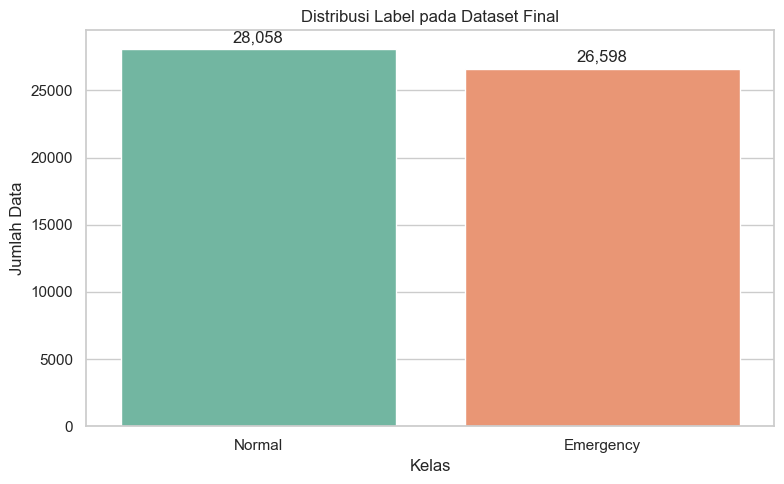

Kesimpulan: Selisih jumlah data antar kelas adalah 1,460 baris; distribusi kelas akhir relatif seimbang untuk pelatihan.


In [4]:
# Menghitung jumlah data pada setiap kelas.
class_summary = eda_df['label_name'].value_counts().rename_axis('label').reset_index(name='jumlah')

# Menghitung persentase agar proporsi kelas mudah dibandingkan.
class_summary['persentase'] = (class_summary['jumlah'] / len(eda_df) * 100).round(2)
display(class_summary)

# Membuat diagram batang jumlah kelas Normal dan Emergency.
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=class_summary, x='label', y='jumlah', hue='label', legend=False)
plt.title('Distribusi Label pada Dataset Final')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Data')
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)
plt.tight_layout()
plt.show()

difference = class_summary['jumlah'].max() - class_summary['jumlah'].min()
print(f'Kesimpulan: Selisih jumlah data antar kelas adalah {difference:,} baris; distribusi kelas akhir relatif seimbang untuk pelatihan.')

In [5]:
# Menghitung indikator kualitas data setelah preprocessing.
quality_summary = pd.DataFrame({
    'indikator': ['Nilai kosong pada teks', 'Teks kosong', 'Duplikat teks persis', 'Teks unik'],
    'jumlah': [
        eda_df['text'].isna().sum(),
        eda_df['text'].astype(str).str.strip().eq('').sum(),
        eda_df.duplicated(subset=['text']).sum(),
        eda_df['text'].nunique(),
    ],
})
display(quality_summary)

# Menghitung panjang teks dalam karakter untuk melihat variasi isi data.
eda_df['panjang_karakter'] = eda_df['text'].astype(str).str.len()
length_summary = eda_df.groupby('label_name')['panjang_karakter'].agg(['count', 'min', 'median', 'mean', 'max']).round(2)
display(length_summary)

print('Kesimpulan: Tabel ini menunjukkan kelengkapan data, kemungkinan duplikasi, dan rentang panjang teks yang akan dipelajari IndoBERT.')

,indikator,jumlah
0,Nilai kosong pada teks,0
1,Teks kosong,0
2,Duplikat teks persis,13
3,Teks unik,54643


,count,min,median,mean,max
label_name,,,,,
Emergency,26598,2,72.0,82.07,494
Normal,28058,1,91.0,93.65,384


Kesimpulan: Tabel ini menunjukkan kelengkapan data, kemungkinan duplikasi, dan rentang panjang teks yang akan dipelajari IndoBERT.


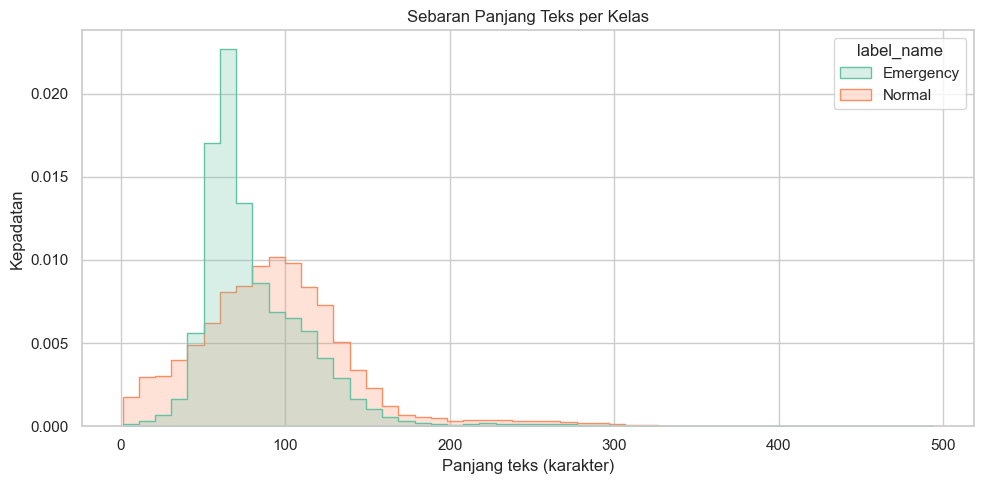

Teks dengan lebih dari 64 kata: 2 dari 54,656
Kesimpulan: Grafik memperlihatkan variasi panjang ujaran. Teks yang sangat panjang dapat dipotong saat tokenisasi karena MAX_LENGTH ditetapkan 64 token.


In [6]:
# Membandingkan sebaran panjang teks antara kelas Normal dan Emergency.
plt.figure(figsize=(10, 5))
sns.histplot(
    data=eda_df,
    x='panjang_karakter',
    hue='label_name',
    bins=50,
    element='step',
    stat='density',
    common_norm=False,
)
plt.title('Sebaran Panjang Teks per Kelas')
plt.xlabel('Panjang teks (karakter)')
plt.ylabel('Kepadatan')
plt.tight_layout()
plt.show()

# Menghitung jumlah teks yang melebihi batas tokenisasi training.
estimated_tokens = eda_df['text'].astype(str).str.split().str.len()
over_64_words = (estimated_tokens > MAX_LENGTH).sum()
print(f'Teks dengan lebih dari {MAX_LENGTH} kata: {over_64_words:,} dari {len(eda_df):,}')
print('Kesimpulan: Grafik memperlihatkan variasi panjang ujaran. Teks yang sangat panjang dapat dipotong saat tokenisasi karena MAX_LENGTH ditetapkan 64 token.')

,label,kata,frekuensi
0,Emergency,tolong,7037
1,Emergency,bantuan,5674
2,Emergency,badai,4945
3,Emergency,sekarang,4474
4,Emergency,orang,4247
5,Emergency,segera,4213
6,Emergency,banjir,4117
7,Emergency,bantu,4040
8,Emergency,evakuasi,3580
9,Emergency,bahaya,3196


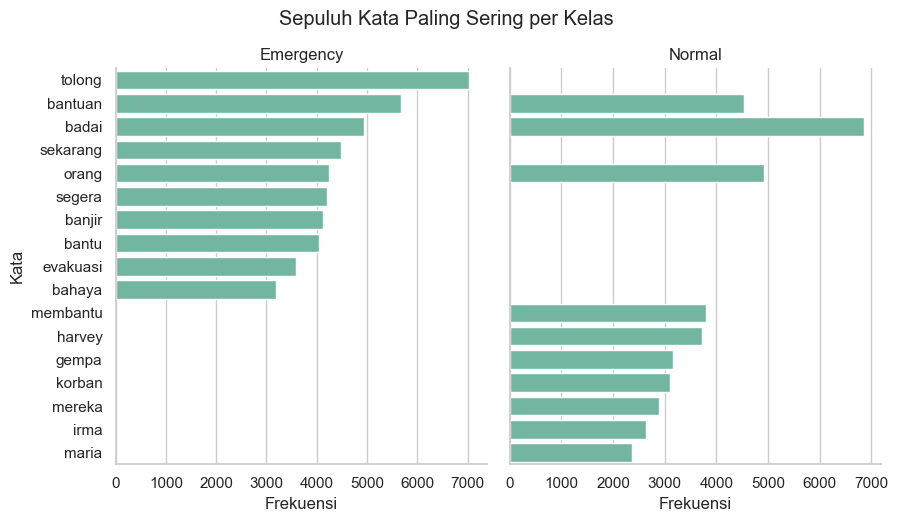

Kesimpulan: Kata yang sering muncul dapat membantu menjelaskan pola bahasa yang membedakan kondisi Normal dan Emergency dalam dataset.


In [7]:
# Menentukan kata umum yang tidak dipakai agar kata bermakna lebih terlihat.
stopwords = {'yang', 'dan', 'di', 'ke', 'dari', 'untuk', 'ini', 'itu', 'ada', 'akan', 'dengan', 'pada', 'saya', 'kami', 'kamu', 'atau', 'sebuah', 'dalam'}

# Fungsi ini mengubah teks menjadi kata huruf kecil dan menghapus angka atau tanda baca.
def extract_words(text):
    words = re.findall(r'[a-zA-Z]+', str(text).lower())
    return [word for word in words if len(word) > 2 and word not in stopwords]

# Mengambil sepuluh kata paling sering untuk setiap kelas.
top_words = []
for label_name, group in eda_df.groupby('label_name'):
    word_counts = Counter(word for text in group['text'] for word in extract_words(text))
    for word, count in word_counts.most_common(10):
        top_words.append({'label': label_name, 'kata': word, 'frekuensi': count})

top_words_df = pd.DataFrame(top_words)
display(top_words_df)

# Menampilkan kata dominan dalam diagram batang terpisah untuk tiap kelas.
g = sns.catplot(
    data=top_words_df,
    kind='bar',
    x='frekuensi',
    y='kata',
    col='label',
    sharex=False,
    height=5,
    aspect=0.9,
)
g.set_axis_labels('Frekuensi', 'Kata')
g.set_titles('{col_name}')
g.fig.suptitle('Sepuluh Kata Paling Sering per Kelas', y=1.04)
plt.show()

print('Kesimpulan: Kata yang sering muncul dapat membantu menjelaskan pola bahasa yang membedakan kondisi Normal dan Emergency dalam dataset.')

## Akhir Visualisasi Dataset Final

Secara keseluruhan, visualisasi ini mendokumentasikan ukuran dataset, keseimbangan label, kualitas teks, variasi panjang teks, dan kata dominan. Hasilnya dapat digunakan sebagai bukti bahwa `dataset_final.csv` telah diperiksa sebelum proses fine-tuning IndoBERT.

In [ ]:
working_df = df
if TRAIN_SAMPLE_SIZE is not None and TRAIN_SAMPLE_SIZE < len(df):
    working_df, _ = train_test_split(
        df,
        train_size=TRAIN_SAMPLE_SIZE,
        stratify=df["label"],
        random_state=SEED,
    )

train_df, temp_df = train_test_split(
    working_df,
    test_size=0.2,
    stratify=working_df["label"],
    random_state=SEED,
)
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=SEED,
)

log(f"Training rows: {len(train_df):,}")
log(f"Validation rows: {len(valid_df):,}")
log(f"Test rows: {len(test_df):,}")

Training rows: 43,724
Validation rows: 5,466
Test rows: 5,466


In [ ]:
class EmergencyTextDataset(Dataset):
    def __init__(self, frame, tokenizer, max_length):
        self.texts = frame["text"].tolist()
        self.labels = frame["label"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        item = {key: value.squeeze(0) for key, value in encoded.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "Normal", 1: "Emergency"},
    label2id={"Normal": 0, "Emergency": 1},
    ignore_mismatched_sizes=True,
)

if FREEZE_BERT_ENCODER:
    for name, parameter in model.named_parameters():
        if not name.startswith("classifier"):
            parameter.requires_grad = False

model.to(device)
train_loader = DataLoader(EmergencyTextDataset(train_df, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(EmergencyTextDataset(valid_df, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE)
test_loader = DataLoader(EmergencyTextDataset(test_df, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE)
log("Model siap dilatih.")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15282.17it/s]


[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model siap dilatih.


In [ ]:
def evaluate_model(model, loader):
    model.eval()
    losses, predictions, labels = [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = {key: value.to(device) for key, value in batch.items()}
            outputs = model(**batch)
            losses.append(outputs.loss.item())
            preds = torch.argmax(outputs.logits, dim=-1)
            predictions.extend(preds.cpu().numpy().tolist())
            labels.extend(batch["labels"].cpu().numpy().tolist())
    return {
        "loss": float(np.mean(losses)),
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions),
        "labels": labels,
        "predictions": predictions,
    }

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
history = []
best_valid_f1 = -1.0
best_epoch = 0
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    model.train()
    train_losses = []
    total_batches = len(train_loader)
    log(f"Epoch {epoch + 1}/{EPOCHS} - {total_batches} batch")
    for step, batch in enumerate(train_loader, start=1):
        batch = {key: value.to(device) for key, value in batch.items()}
        optimizer.zero_grad()
        outputs = model(**batch)
        outputs.loss.backward()
        optimizer.step()
        train_losses.append(outputs.loss.item())
        if step == 1 or step % 10 == 0 or step == total_batches:
            log(f"  step {step:>3}/{total_batches} loss={np.mean(train_losses):.4f}")

    valid_metrics = evaluate_model(model, valid_loader)
    row = {
        "epoch": epoch + 1,
        "train_loss": float(np.mean(train_losses)),
        "valid_loss": valid_metrics["loss"],
        "valid_accuracy": valid_metrics["accuracy"],
        "valid_f1": valid_metrics["f1"],
    }
    history.append(row)
    if valid_metrics["f1"] > best_valid_f1:
        best_valid_f1 = valid_metrics["f1"]
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
    log(row)

model.load_state_dict(best_model_state)
log(f"Model terbaik memakai epoch {best_epoch} dengan validation F1 {best_valid_f1:.4f}")
pd.DataFrame(history)

Epoch 1/1 - 5466 batch

  step   1/5466 loss=0.8628


  step  10/5466 loss=0.6292


  step  20/5466 loss=0.5757


  step  30/5466 loss=0.4846


...

  step 5450/5466 loss=0.2819


  step 5460/5466 loss=0.2818


  step 5466/5466 loss=0.2818


{'epoch': 1, 'train_loss': 0.2818478734583137, 'valid_loss': 0.2535136306892579, 'valid_accuracy': 0.8929747530186608, 'valid_f1': 0.8871745419479267}
Model terbaik memakai epoch 1 dengan validation F1 0.8872


,epoch,train_loss,valid_loss,valid_accuracy,valid_f1
0,1,0.281848,0.253514,0.892975,0.887175


In [ ]:
test_metrics = evaluate_model(model, test_loader)
log(f"Test accuracy: {test_metrics['accuracy']:.4f}")
log(f"Test F1: {test_metrics['f1']:.4f}")
log("Confusion matrix [Normal, Emergency]:")
log(confusion_matrix(test_metrics["labels"], test_metrics["predictions"]))
log(classification_report(test_metrics["labels"], test_metrics["predictions"], target_names=["Normal", "Emergency"]))

Test accuracy: 0.9061
Test F1: 0.9014
Confusion matrix [Normal, Emergency]:
[[2609  197]
 [ 316 2344]]
              precision    recall  f1-score   support

      Normal       0.89      0.93      0.91      2806
   Emergency       0.92      0.88      0.90      2660

    accuracy                           0.91      5466
   macro avg       0.91      0.91      0.91      5466
weighted avg       0.91      0.91      0.91      5466



In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

metadata = {
    "dataset_path": str(DATASET_PATH),
    "base_model": MODEL_NAME,
    "train_sample_size": TRAIN_SAMPLE_SIZE,
    "freeze_bert_encoder": FREEZE_BERT_ENCODER,
    "max_length": MAX_LENGTH,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "best_epoch": best_epoch,
    "best_valid_f1": best_valid_f1,
    "test_accuracy": test_metrics["accuracy"],
    "test_f1": test_metrics["f1"],
}
pd.Series(metadata).to_json(OUTPUT_DIR / "training_metadata.json", indent=2)
log(f"Model tersimpan di: {OUTPUT_DIR}")
log("Set BERT_MODEL_NAME=backend/bert/trained_model_indobert_full di .env untuk memakai model ini.")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.19it/s]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.18it/s]

Model tersimpan di: C:\Users\L E N O V O\Documents\Arduino\machine_learning\backend\bert\trained_model_indobert_full
Set BERT_MODEL_NAME=backend/bert/trained_model_indobert_full di .env untuk memakai model ini.


In [ ]:
def predict(text):
    model.eval()
    encoded = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=MAX_LENGTH)
    encoded = {key: value.to(device) for key, value in encoded.items()}
    with torch.no_grad():
        logits = model(**encoded).logits
        probs = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
    pred_id = int(np.argmax(probs))
    return {"text": text, "prediction": model.config.id2label[pred_id], "confidence": float(probs[pred_id])}

pd.DataFrame([
    predict("tolong ada kebakaran besar di dekat rumah saya"),
    predict("semua aman tidak ada keadaan darurat"),
])

,text,prediction,confidence
0,tolong ada kebakaran besar di dekat rumah saya,Emergency,0.733590
1,semua aman tidak ada keadaan darurat,Normal,0.833148


## Materi Slide Training BERT dan Hasil Training

Bagian ini dibuat untuk bahan slide setelah pembahasan dataset. Fokusnya adalah menjelaskan proses training model IndoBERT, hasil evaluasi, confusion matrix, serta aturan threshold yang dipakai saat sistem berjalan real-time.

### Isi Slide: Training Model BERT

- **Judul slide:** Training Model BERT
- **Inti pembahasan:** Dataset final dilatih menggunakan IndoBERT untuk membedakan teks **Normal** dan **Emergency**.
- **Model yang digunakan:** `indobenchmark/indobert-base-p1`
- **Jenis training:** Full fine-tuning, yaitu seluruh encoder IndoBERT ikut dilatih.
- **Pembagian data:** Train 80%, validation 10%, dan test 10%.
- **Parameter utama:** Max length 64 token, batch size 8, epoch 1.
- **Output:** Model tersimpan di `backend/bert/trained_model_indobert_full`.

**Kalimat singkat untuk presentasi:** Model IndoBERT dilatih ulang menggunakan dataset final agar mampu mengenali teks normal dan teks darurat pada konteks keselamatan pekerja.

### Isi Slide: Hasil Training

- **Judul slide:** Hasil Training Model
- **Metrik utama:** Test accuracy 90,61% dan Test F1-score 90,14%.
- **Validation score:** Validation accuracy 89,30% dan Validation F1-score 88,72%.
- **Confusion matrix:** Menunjukkan jumlah prediksi benar dan salah untuk kelas Normal dan Emergency.
- **Interpretasi:** Model sudah cukup baik karena performa kedua kelas relatif seimbang.
- **Threshold sistem:** Emergency langsung aktif jika confidence lebih dari 0,85, atau 2 chunk berturut-turut lebih dari 0,7.

**Kalimat singkat untuk presentasi:** Hasil evaluasi menunjukkan model mampu mengklasifikasikan kondisi darurat dan normal dengan performa sekitar 90% pada data test.

In [1]:
# Visualisasi ringkasan konfigurasi training untuk bahan slide.
# Cell ini tidak menjalankan training ulang, hanya membaca dataset final dan metadata model yang sudah tersimpan.
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
DATASET_PATH = PROJECT_ROOT / "dataset" / "dataset_final.csv"
METADATA_PATH = PROJECT_ROOT / "backend" / "bert" / "trained_model_indobert_full" / "training_metadata.json"

slide_df = pd.read_csv(DATASET_PATH)
with METADATA_PATH.open("r", encoding="utf-8") as metadata_file:
    training_metadata = json.load(metadata_file)

total_data = len(slide_df)
train_rows = int(total_data * 0.8)
valid_rows = int(total_data * 0.1)
test_rows = total_data - train_rows - valid_rows

training_summary = pd.DataFrame({
    "Komponen": [
        "Model dasar",
        "Jenis training",
        "Jumlah dataset",
        "Data train",
        "Data validation",
        "Data test",
        "Max length",
        "Batch size",
        "Epoch",
    ],
    "Nilai": [
        training_metadata["base_model"],
        "Full fine-tuning",
        f"{total_data:,} data",
        f"{train_rows:,} data",
        f"{valid_rows:,} data",
        f"{test_rows:,} data",
        f"{training_metadata['max_length']} token",
        training_metadata["batch_size"],
        training_metadata["epochs"],
    ],
})

display(training_summary.style.hide(axis="index"))
print("Kesimpulan: Tabel ini menjelaskan konfigurasi utama training IndoBERT yang digunakan pada proyek.")

Komponen,Nilai
Model dasar,indobenchmark/indobert-base-p1
Jenis training,Full fine-tuning
Jumlah dataset,"54,656 data"
Data train,"43,724 data"
Data validation,"5,465 data"
Data test,"5,467 data"
Max length,64 token
Batch size,8
Epoch,1


Kesimpulan: Tabel ini menjelaskan konfigurasi utama training IndoBERT yang digunakan pada proyek.


C:\Users\LENOVO~1\AppData\Local\Temp\ipykernel_5164\1614534710.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=split_df, x="Bagian Data", y="Jumlah", palette=colors)


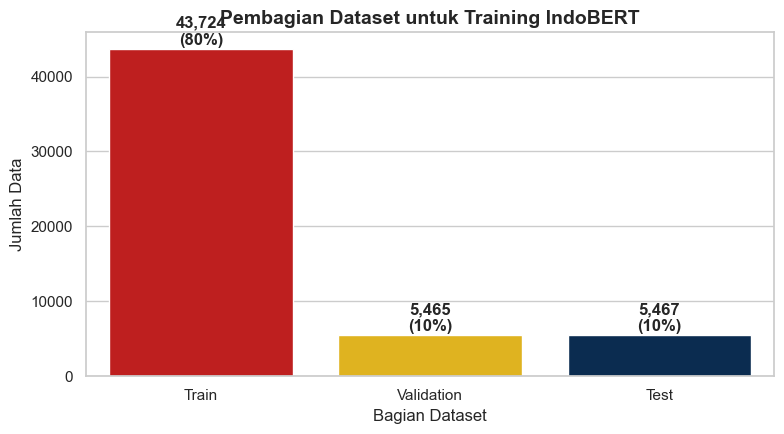

Kesimpulan: Dataset dibagi menjadi 80% data latih, 10% validasi, dan 10% pengujian agar performa model dapat dievaluasi secara terpisah.


In [2]:
# Visualisasi pembagian dataset train, validation, dan test.
# Tujuannya agar audiens mudah melihat bahwa data dibagi untuk training dan evaluasi model.
split_df = pd.DataFrame({
    "Bagian Data": ["Train", "Validation", "Test"],
    "Jumlah": [train_rows, valid_rows, test_rows],
    "Persentase": [80, 10, 10],
})

plt.figure(figsize=(8, 4.5))
colors = ["#d90404", "#ffc400", "#002b5b"]
ax = sns.barplot(data=split_df, x="Bagian Data", y="Jumlah", palette=colors)

for index, row in split_df.iterrows():
    ax.text(index, row["Jumlah"] + 500, f"{row['Jumlah']:,}\n({row['Persentase']}%)", ha="center", fontweight="bold")

plt.title("Pembagian Dataset untuk Training IndoBERT", fontsize=14, fontweight="bold")
plt.xlabel("Bagian Dataset")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()

print("Kesimpulan: Dataset dibagi menjadi 80% data latih, 10% validasi, dan 10% pengujian agar performa model dapat dievaluasi secara terpisah.")

C:\Users\LENOVO~1\AppData\Local\Temp\ipykernel_5164\3396625143.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=metrics_df, x="Metrik", y="Persentase", palette=["#ffc400", "#ffc400", "#d90404", "#d90404"])


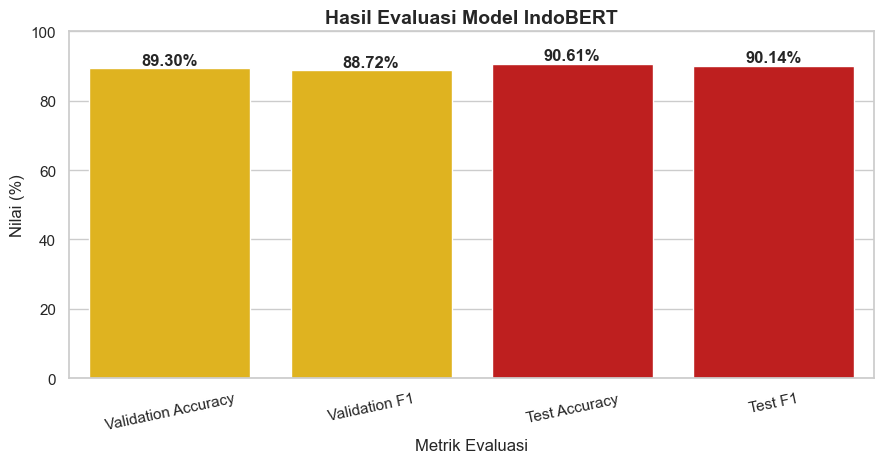

,Metrik,Persentase
0,Validation Accuracy,89.30
1,Validation F1,88.72
2,Test Accuracy,90.61
3,Test F1,90.14


Kesimpulan: Model mencapai Test Accuracy 90,61% dan Test F1-score 90,14%, sehingga performanya cukup kuat untuk klasifikasi teks darurat.


In [3]:
# Visualisasi hasil evaluasi model.
# Grafik ini merangkum performa validation dan test dalam bentuk persentase.
metrics_df = pd.DataFrame({
    "Metrik": ["Validation Accuracy", "Validation F1", "Test Accuracy", "Test F1"],
    "Nilai": [
        0.8929747530,
        training_metadata["best_valid_f1"],
        training_metadata["test_accuracy"],
        training_metadata["test_f1"],
    ],
})
metrics_df["Persentase"] = metrics_df["Nilai"] * 100

plt.figure(figsize=(9, 4.8))
ax = sns.barplot(data=metrics_df, x="Metrik", y="Persentase", palette=["#ffc400", "#ffc400", "#d90404", "#d90404"])
ax.set_ylim(0, 100)

for index, row in metrics_df.iterrows():
    ax.text(index, row["Persentase"] + 1, f"{row['Persentase']:.2f}%", ha="center", fontweight="bold")

plt.title("Hasil Evaluasi Model IndoBERT", fontsize=14, fontweight="bold")
plt.xlabel("Metrik Evaluasi")
plt.ylabel("Nilai (%)")
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

display(metrics_df.assign(Persentase=metrics_df["Persentase"].round(2))[["Metrik", "Persentase"]])
print("Kesimpulan: Model mencapai Test Accuracy 90,61% dan Test F1-score 90,14%, sehingga performanya cukup kuat untuk klasifikasi teks darurat.")

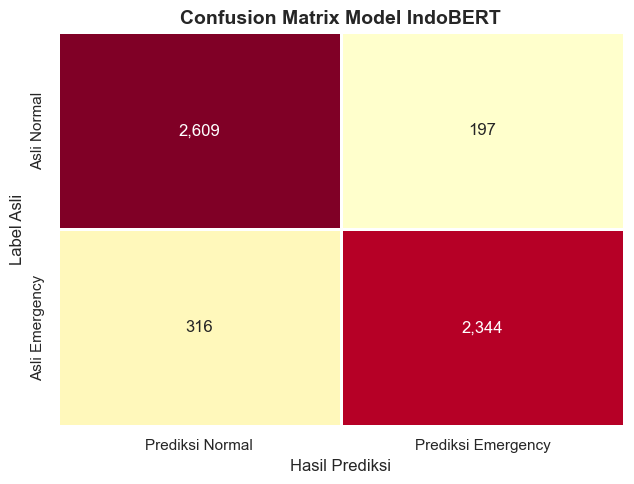

,Prediksi Normal,Prediksi Emergency
Asli Normal,2609,197
Asli Emergency,316,2344


Kesimpulan: Model berhasil mengenali 2.609 data Normal dan 2.344 data Emergency dengan benar, meskipun masih ada sebagian kecil prediksi yang tertukar.


In [4]:
# Visualisasi confusion matrix.
# Baris menunjukkan label asli, sedangkan kolom menunjukkan hasil prediksi model.
confusion = pd.DataFrame(
    [[2609, 197], [316, 2344]],
    index=["Asli Normal", "Asli Emergency"],
    columns=["Prediksi Normal", "Prediksi Emergency"],
)

plt.figure(figsize=(6.5, 5))
ax = sns.heatmap(confusion, annot=True, fmt=",", cmap="YlOrRd", cbar=False, linewidths=1, linecolor="white")
plt.title("Confusion Matrix Model IndoBERT", fontsize=14, fontweight="bold")
plt.xlabel("Hasil Prediksi")
plt.ylabel("Label Asli")
plt.tight_layout()
plt.show()

display(confusion)
print("Kesimpulan: Model berhasil mengenali 2.609 data Normal dan 2.344 data Emergency dengan benar, meskipun masih ada sebagian kecil prediksi yang tertukar.")

C:\Users\LENOVO~1\AppData\Local\Temp\ipykernel_5164\2060206340.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=threshold_df, x="Kondisi Confidence", y="Nilai Urgensi", palette=["#d90404", "#ffc400", "#2e7d32"])


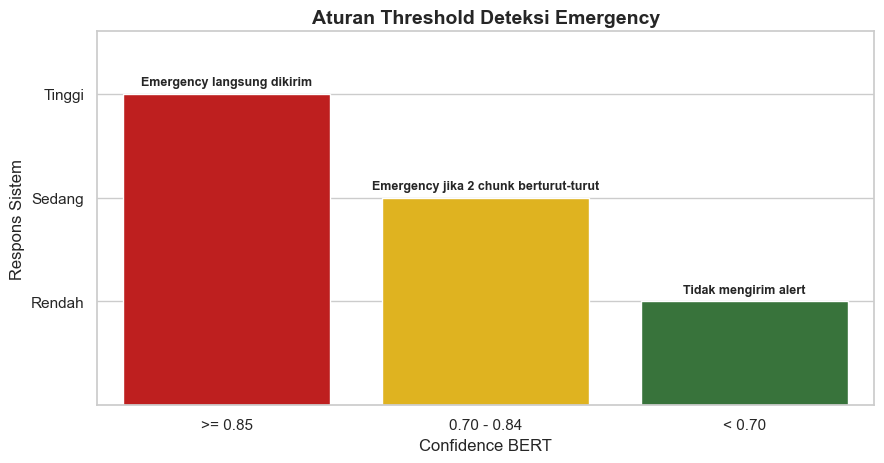

,Kondisi Confidence,Keputusan Sistem
0,>= 0.85,Emergency langsung dikirim
1,0.70 - 0.84,Emergency jika 2 chunk berturut-turut
2,< 0.70,Tidak mengirim alert


Kesimpulan: Sistem dibuat responsif untuk confidence tinggi, tetapi tetap menekan false alarm dengan aturan dua chunk pada confidence menengah.


In [5]:
# Visualisasi aturan threshold saat sistem berjalan.
# Threshold ini digunakan setelah BERT menghasilkan label dan confidence dari setiap chunk audio.
threshold_df = pd.DataFrame({
    "Kondisi Confidence": [">= 0.85", "0.70 - 0.84", "< 0.70"],
    "Keputusan Sistem": [
        "Emergency langsung dikirim",
        "Emergency jika 2 chunk berturut-turut",
        "Tidak mengirim alert",
    ],
    "Nilai Urgensi": [3, 2, 1],
})

plt.figure(figsize=(9, 4.8))
ax = sns.barplot(data=threshold_df, x="Kondisi Confidence", y="Nilai Urgensi", palette=["#d90404", "#ffc400", "#2e7d32"])
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(["Rendah", "Sedang", "Tinggi"])

for index, row in threshold_df.iterrows():
    ax.text(index, row["Nilai Urgensi"] + 0.08, row["Keputusan Sistem"], ha="center", fontweight="bold", fontsize=9)

plt.title("Aturan Threshold Deteksi Emergency", fontsize=14, fontweight="bold")
plt.xlabel("Confidence BERT")
plt.ylabel("Respons Sistem")
plt.ylim(0, 3.6)
plt.tight_layout()
plt.show()

display(threshold_df[["Kondisi Confidence", "Keputusan Sistem"]])
print("Kesimpulan: Sistem dibuat responsif untuk confidence tinggi, tetapi tetap menekan false alarm dengan aturan dua chunk pada confidence menengah.")

In [6]:
# Contoh teks uji yang dapat ditampilkan pada slide.
# Tabel ini membantu menjelaskan bentuk input teks setelah suara ditranskripsi oleh Whisper.
example_predictions = pd.DataFrame({
    "Contoh Teks": [
        "tolong ada kebakaran besar di dekat saya",
        "pekerja jatuh dan butuh bantuan",
        "semua aman tidak ada keadaan darurat",
        "ini bukan keadaan darurat hanya latihan",
    ],
    "Target yang Diharapkan": ["Emergency", "Emergency", "Normal", "Normal"],
    "Alasan": [
        "Mengandung permintaan tolong dan kebakaran",
        "Mengandung kecelakaan dan kebutuhan bantuan",
        "Mengandung konteks aman dan negasi darurat",
        "Mengandung negasi bahwa kondisi bukan darurat",
    ],
})

display(example_predictions.style.hide(axis="index"))
print("Kesimpulan: Contoh ini menunjukkan bahwa model tidak hanya melihat kata bahaya, tetapi juga perlu memahami konteks kalimat dan negasi.")

Contoh Teks,Target yang Diharapkan,Alasan
tolong ada kebakaran besar di dekat saya,Emergency,Mengandung permintaan tolong dan kebakaran
pekerja jatuh dan butuh bantuan,Emergency,Mengandung kecelakaan dan kebutuhan bantuan
semua aman tidak ada keadaan darurat,Normal,Mengandung konteks aman dan negasi darurat
ini bukan keadaan darurat hanya latihan,Normal,Mengandung negasi bahwa kondisi bukan darurat


Kesimpulan: Contoh ini menunjukkan bahwa model tidak hanya melihat kata bahaya, tetapi juga perlu memahami konteks kalimat dan negasi.
